# 04. Dashboard Visualization

Generates:
- `output/dashboard_1D.png`
- `output/dashboard_7D.png`
- `output/dashboard_1M.png`
- `output/dashboard_3M.png`
- `output/chart_1D.png` … `chart_3M.png` (standalone timeseries)

Color palette matches the `Crypto Sentiment Dashboard.html` mockup.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import json
from pathlib import Path
from IPython.display import Image, display as ipy_display

from src.collector import load_klines, fetch_binance_ticker_24h
from src.sentiment import load_sentiment_results
from src.analyzer import (
    aggregate_to_windows,
    compute_correlations,
    compute_period_performance,
    load_merged_analysis,
)
from src.visualizer import run_full_visualization, build_dashboard

BASE_DIR = Path('..').resolve()
PROC = BASE_DIR / 'data' / 'processed'

## 1. Load All Required Data

In [2]:
klines_1h    = load_klines('1h')
sentiment_df = load_sentiment_results()
merged_df    = load_merged_analysis()

# Live ticker
try:
    ticker = fetch_binance_ticker_24h()
except Exception:
    ticker = {}

# CoinGecko market stats (saved by collector)
market_path = PROC / 'market_stats.json'
market = json.loads(market_path.read_text()) if market_path.exists() else {}

print('Data loaded successfully.')
print(f'  klines_1h   : {len(klines_1h):,} rows')
print(f'  sentiment   : {len(sentiment_df):,} rows')
print(f'  merged      : {len(merged_df):,} rows')
print(f'  ticker price: ${ticker.get("price", 0):,.2f}')

2026-04-21 09:22:54,471 [INFO] Loaded 75907 kline rows (1h) from 105 files


Data loaded successfully.
  klines_1h   : 75,907 rows
  sentiment   : 30 rows
  merged      : 17 rows
  ticker price: $75,882.00


## 2. Prepare Analysis Inputs

In [3]:
windows_df = aggregate_to_windows(sentiment_df, window_minutes=5)
corr_df    = compute_correlations(merged_df)
period_df  = compute_period_performance(klines_1h, sentiment_df)

# Recent valid headlines for gauge panel
recent = (
    sentiment_df[sentiment_df['is_valid']]
    .sort_values('published_at', ascending=False)
    .head(5)[['title', 'score', 'sentiment_label', 'published_at']]
    .to_dict('records')
)

display(corr_df)

2026-04-21 09:22:54,640 [INFO] Aggregated 17 valid news → 17 windows (5-min)
2026-04-21 09:22:54,642 [WARNING] Lag T+5m: only 17 rows — skipping
2026-04-21 09:22:54,643 [WARNING] Lag T+15m: only 17 rows — skipping
2026-04-21 09:22:54,647 [WARNING] Lag T+30m: only 17 rows — skipping
2026-04-21 09:22:54,648 [WARNING] Lag T+60m: only 17 rows — skipping


,lag_min,r,p_value,n,significant
0,5,NaN,NaN,17,False
1,15,NaN,NaN,17,False
2,30,NaN,NaN,17,False
3,60,NaN,NaN,17,False


## 3. Generate All Dashboard PNGs

In [4]:
run_full_visualization(
    klines_df=klines_1h,
    windows_df=windows_df,
    merged_df=merged_df,
    corr_df=corr_df,
    period_df=period_df,
    ticker=ticker,
    market=market,
    recent_headlines=recent,
)
print('All charts saved to output/')

c:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\notebooks\..\src\visualizer.py:440: UserWarning: Glyph 8383 (\N{BITCOIN SIGN}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(out_path, dpi=100, facecolor=P["bg"], bbox_inches="tight")
2026-04-21 09:22:56,150 [INFO] Dashboard saved → C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\output\dashboard_1D.png
c:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\notebooks\..\src\visualizer.py:440: UserWarning: Glyph 8383 (\N{BITCOIN SIGN}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(out_path, dpi=100, facecolor=P["bg"], bbox_inches="tight")
2026-04-21 09:22:57,333 [INFO] Dashboard saved → C:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\output\dashboard_7D.png
c:\Users\조동희\Desktop\KOSTA\프로젝트\Crypto-Trend-Analysis\notebooks\..\src\visualizer.py:440: UserWarning: Glyph 8383 (\N{BITCOIN SIGN}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(out_path, dpi=100, facecolor=P["bg"], bbox_inches="tight")
2026-04-21 

All charts saved to output/


## 4. Preview Dashboard (7D)

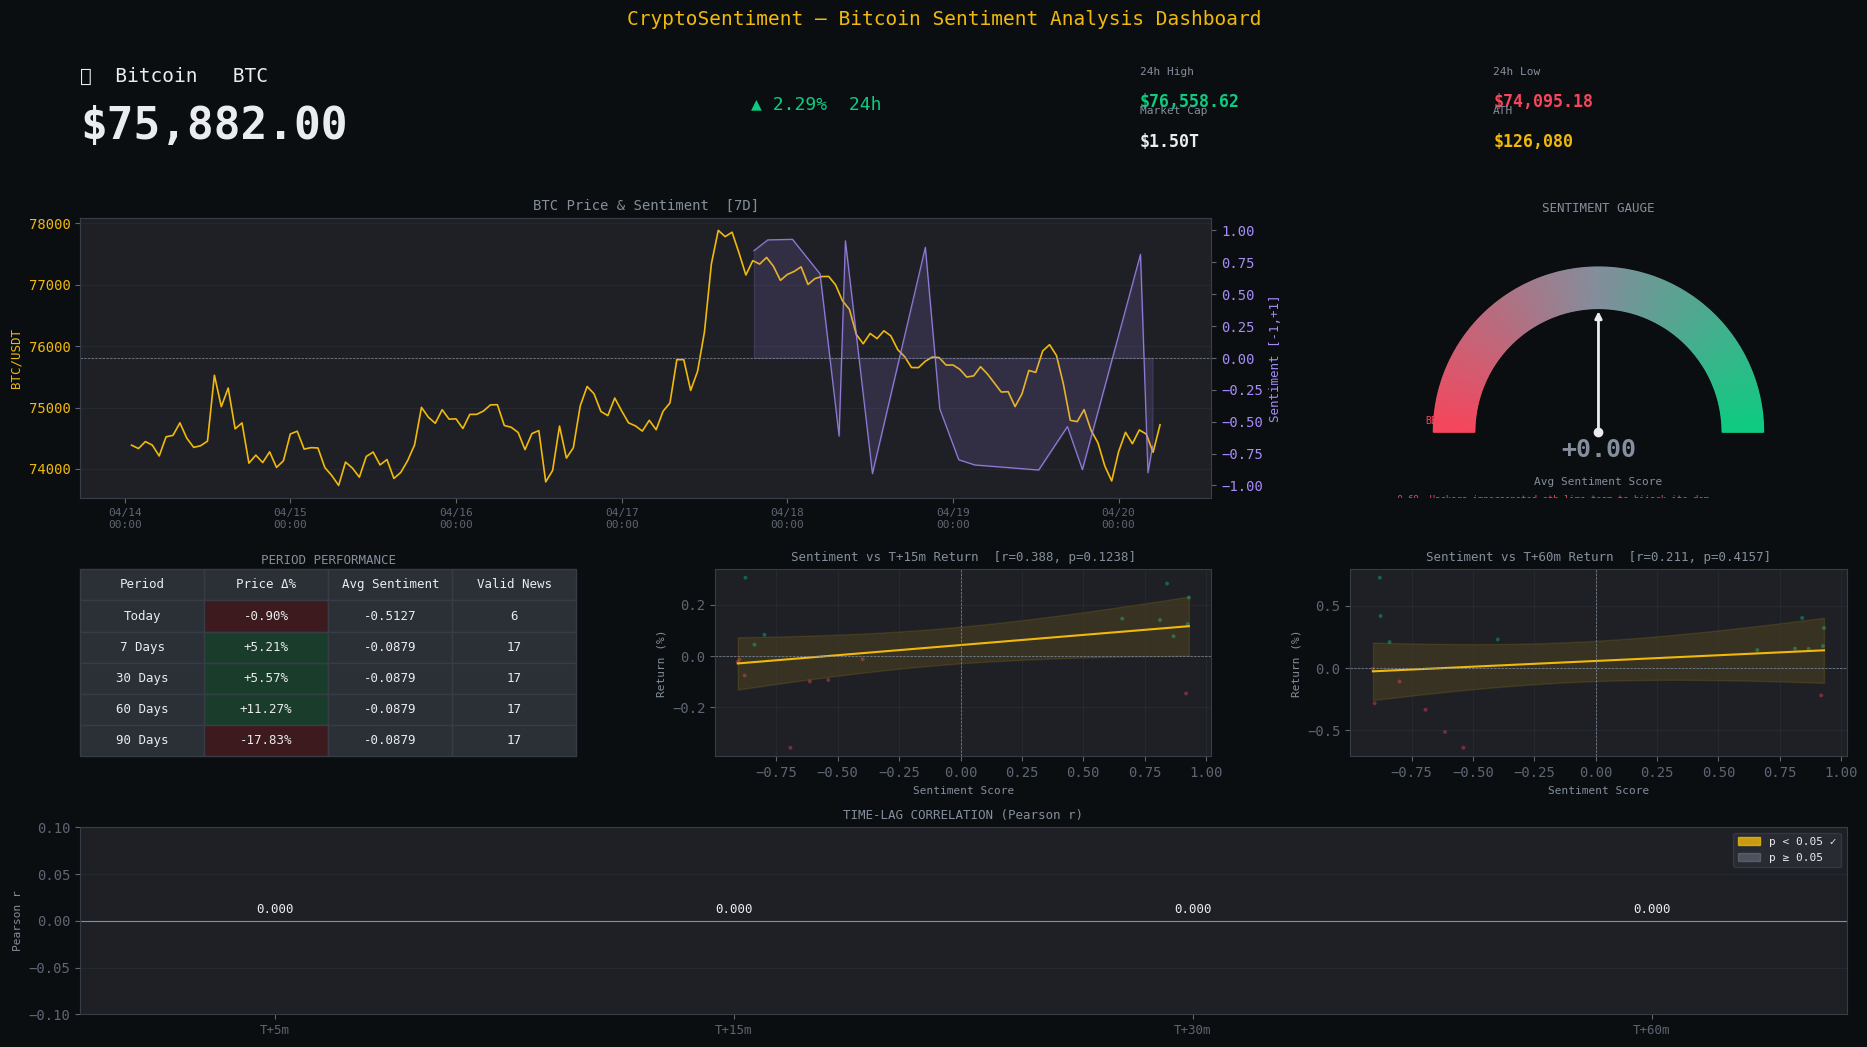

In [5]:
ipy_display(Image(filename=str(BASE_DIR / 'output' / 'dashboard_7D.png'), width=1200))

## 5. Preview — Standalone Chart (7D)

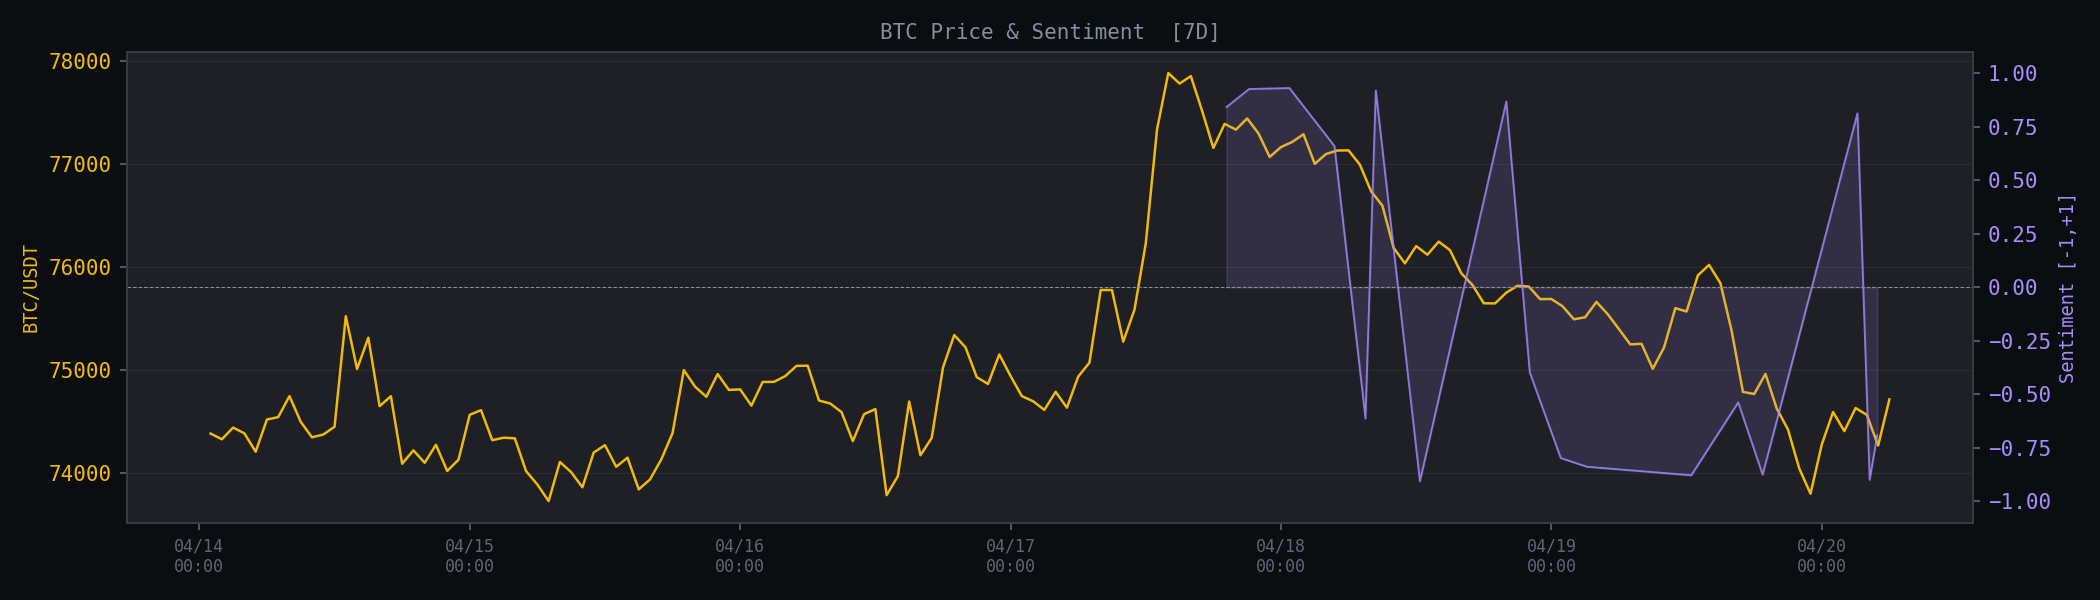

In [6]:
ipy_display(Image(filename=str(BASE_DIR / 'output' / 'chart_7D.png'), width=1000))